# Video Swin Transformer — Spatial Augmentation Experiment

This notebook evaluates **training-only spatial augmentation** for cricket shot classification using the same Swin3D-T baseline architecture and dataset split.

**Experiment change:** random spatial transformations are applied consistently across all 32 frames of each training clip. Validation and test preprocessing remain deterministic and unchanged from the baseline.


## 1. Environment and Experiment Setup


In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import swin3d_t, Swin3D_T_Weights

print("=" * 60)
print("SPATIAL AUGMENTATION EXPERIMENT")
print("=" * 60)

print("PyTorch    :", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA       :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DATASET_ROOT = (
    "/kaggle/input/datasets/nivrithakunduru/"
    "cricket-shot-classification-dataset/dataset"
)

print("\nDataset exists:", os.path.exists(DATASET_ROOT))
print("Device        :", device)

SPATIAL AUGMENTATION EXPERIMENT
PyTorch    : 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA       : True
GPU        : Tesla T4

Dataset exists: True
Device        : cuda


## 2. Spatial Augmentation Pipeline


In [2]:
import random
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


# ============================================================
# VIDEO SWIN PRETRAINED NORMALIZATION
# ============================================================

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

weights = Swin3D_T_Weights.DEFAULT

# Validation/Test remain EXACTLY like baseline
val_test_transform = weights.transforms()


# ============================================================
# TRAINING-ONLY SPATIAL AUGMENTATION
# ============================================================

class VideoSpatialAugmentation:

    def __init__(
        self,
        output_size=224,
        resize_size=256,
        crop_scale=(0.80, 1.00),
        horizontal_flip_prob=0.5,
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ):

        self.output_size = output_size
        self.resize_size = resize_size
        self.crop_scale = crop_scale

        self.horizontal_flip_prob = horizontal_flip_prob

        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation


    def __call__(self, video):

        # Input:
        # [T, C, H, W], uint8

        video = video.float() / 255.0

        T, C, H, W = video.shape


        # ----------------------------------------------------
        # 1. Resize shorter side to 256
        # ----------------------------------------------------

        if H < W:
            new_h = self.resize_size
            new_w = int(
                W * self.resize_size / H
            )
        else:
            new_w = self.resize_size
            new_h = int(
                H * self.resize_size / W
            )

        video = TF.resize(
            video,
            [new_h, new_w],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        )


        # ----------------------------------------------------
        # 2. SAME random crop for all 32 frames
        # ----------------------------------------------------

        scale = random.uniform(
            self.crop_scale[0],
            self.crop_scale[1]
        )

        crop_h = int(new_h * scale)
        crop_w = int(new_w * scale)

        crop_h = min(crop_h, new_h)
        crop_w = min(crop_w, new_w)

        top = random.randint(
            0,
            new_h - crop_h
        )

        left = random.randint(
            0,
            new_w - crop_w
        )

        video = TF.resized_crop(
            video,
            top,
            left,
            crop_h,
            crop_w,
            [self.output_size, self.output_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        )


        # ----------------------------------------------------
        # 3. SAME horizontal flip for entire video
        # ----------------------------------------------------

        if random.random() < self.horizontal_flip_prob:
            video = TF.hflip(video)


        # ----------------------------------------------------
        # 4. SAME mild color jitter for entire video
        # ----------------------------------------------------

        brightness_factor = random.uniform(
            1 - self.brightness,
            1 + self.brightness
        )

        contrast_factor = random.uniform(
            1 - self.contrast,
            1 + self.contrast
        )

        saturation_factor = random.uniform(
            1 - self.saturation,
            1 + self.saturation
        )

        video = TF.adjust_brightness(
            video,
            brightness_factor
        )

        video = TF.adjust_contrast(
            video,
            contrast_factor
        )

        video = TF.adjust_saturation(
            video,
            saturation_factor
        )

        video = torch.clamp(
            video,
            0.0,
            1.0
        )


        # ----------------------------------------------------
        # 5. Normalize using pretrained Kinetics statistics
        # ----------------------------------------------------

        mean = torch.tensor(
            MEAN,
            dtype=video.dtype,
            device=video.device
        ).view(1, 3, 1, 1)

        std = torch.tensor(
            STD,
            dtype=video.dtype,
            device=video.device
        ).view(1, 3, 1, 1)

        video = (
            video - mean
        ) / std


        # ----------------------------------------------------
        # Swin3D expects [C, T, H, W]
        # ----------------------------------------------------

        video = video.permute(
            1, 0, 2, 3
        )

        return video


train_transform = VideoSpatialAugmentation()


print("✅ Training transform  : Spatial augmentation")
print("✅ Validation transform:", val_test_transform)
print("✅ Test transform      :", val_test_transform)

✅ Training transform  : Spatial augmentation
✅ Validation transform: VideoClassification(
    crop_size=[224, 224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
✅ Test transform      : VideoClassification(
    crop_size=[224, 224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 3. Dataset


In [3]:
# ============================================================
# DATASET CLASS
# ============================================================

class CricketVideoDataset(Dataset):

    def __init__(
        self,
        root_dir,
        classes,
        transform,
        num_frames=32
    ):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.num_frames = num_frames

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(classes)
        }

        self.samples = []

        for class_name in classes:

            class_dir = os.path.join(
                root_dir,
                class_name
            )

            if not os.path.isdir(class_dir):
                continue

            for filename in sorted(os.listdir(class_dir)):

                if filename.lower().endswith(
                    (".avi", ".mp4", ".mov", ".mkv")
                ):

                    self.samples.append(
                        (
                            os.path.join(class_dir, filename),
                            self.class_to_idx[class_name]
                        )
                    )

        print(
            f"Loaded {len(self.samples)} videos "
            f"from {root_dir}"
        )


    def __len__(self):
        return len(self.samples)


    def load_video(self, video_path):

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(
                f"Cannot read video: {video_path}"
            )

        # Keep temporal sampling EXACTLY same as baseline
        indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_idx in indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_idx)
            )

            success, frame = cap.read()

            if not success:
                continue

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            raise RuntimeError(
                f"No frames decoded: {video_path}"
            )

        while len(frames) < self.num_frames:
            frames.append(
                frames[-1].copy()
            )

        return np.stack(
            frames[:self.num_frames]
        )


    def __getitem__(self, idx):

        video_path, label = self.samples[idx]

        frames = self.load_video(video_path)

        # [T,H,W,C] -> [T,C,H,W]
        video = torch.from_numpy(
            frames
        ).permute(0, 3, 1, 2)

        video = self.transform(video)

        return video, label


# ============================================================
# PATHS + CLASSES
# ============================================================

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

CLASSES = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep"
]


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = CricketVideoDataset(
    TRAIN_DIR,
    CLASSES,
    train_transform,
    num_frames=32
)

val_dataset = CricketVideoDataset(
    VAL_DIR,
    CLASSES,
    val_test_transform,
    num_frames=32
)

test_dataset = CricketVideoDataset(
    TEST_DIR,
    CLASSES,
    val_test_transform,
    num_frames=32
)


print("\nTrain:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Loaded 1321 videos from /kaggle/input/datasets/nivrithakunduru/cricket-shot-classification-dataset/dataset/train
Loaded 283 videos from /kaggle/input/datasets/nivrithakunduru/cricket-shot-classification-dataset/dataset/val
Loaded 284 videos from /kaggle/input/datasets/nivrithakunduru/cricket-shot-classification-dataset/dataset/test

Train: 1321
Val  : 283
Test : 284


### Augmentation Sanity Check


In [4]:
# ============================================================
# AUGMENTATION SANITY CHECK
# ============================================================

video_1, label_1 = train_dataset[0]
video_2, label_2 = train_dataset[0]

print("Video 1 shape:", video_1.shape)
print("Video 2 shape:", video_2.shape)

print("Video 1 dtype:", video_1.dtype)

print("Label 1:", label_1)
print("Label 2:", label_2)

difference = torch.mean(
    torch.abs(video_1 - video_2)
).item()

print(
    f"\nMean difference between two augmented "
    f"versions: {difference:.6f}"
)

print(
    "Outputs identical:",
    torch.equal(video_1, video_2)
)

Video 1 shape: torch.Size([3, 32, 224, 224])
Video 2 shape: torch.Size([3, 32, 224, 224])
Video 1 dtype: torch.float32
Label 1: 0
Label 2: 0

Mean difference between two augmented versions: 0.512277
Outputs identical: False


### Visualizing Two Augmented Views


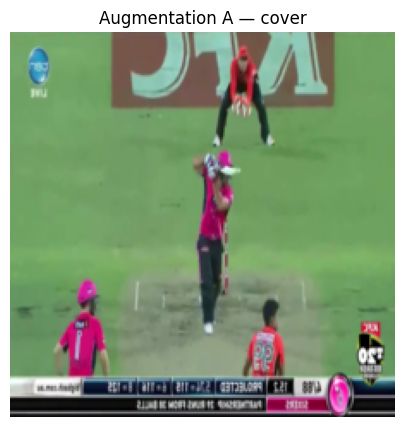

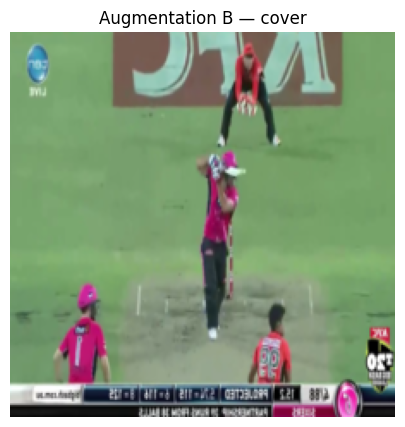

In [5]:
import matplotlib.pyplot as plt

# Get two independently augmented versions
video_a, label = train_dataset[0]
video_b, _ = train_dataset[0]

# Middle frame
frame_idx = 16


def denormalize(frame):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)

    frame = frame * std + mean
    frame = torch.clamp(frame, 0, 1)

    return frame.permute(1, 2, 0).numpy()


frame_a = denormalize(
    video_a[:, frame_idx]
)

frame_b = denormalize(
    video_b[:, frame_idx]
)


plt.figure(figsize=(6, 5))
plt.imshow(frame_a)
plt.title(
    f"Augmentation A — {CLASSES[label]}"
)
plt.axis("off")
plt.show()


plt.figure(figsize=(6, 5))
plt.imshow(frame_b)
plt.title(
    f"Augmentation B — {CLASSES[label]}"
)
plt.axis("off")
plt.show()

## 4. DataLoaders and Output Paths


In [6]:
# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


# ============================================================
# SEPARATE SAVE DIRECTORY
# ============================================================

SAVE_DIR = "/kaggle/working/video_swin_spatial_aug"

os.makedirs(SAVE_DIR, exist_ok=True)

LATEST_PATH = os.path.join(
    SAVE_DIR,
    "spatial_aug_latest.pth"
)

BEST_PATH = os.path.join(
    SAVE_DIR,
    "spatial_aug_best.pth"
)

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "spatial_aug_history.json"
)

CONFIG_PATH = os.path.join(
    SAVE_DIR,
    "spatial_aug_config.json"
)

print("\nSave directory:", SAVE_DIR)

Train batches: 661
Val batches  : 142
Test batches : 142

Save directory: /kaggle/working/video_swin_spatial_aug


## 5. Model and Training Configuration


In [8]:
import json
import time


# ============================================================
# FRESH VIDEO SWIN-T
# ============================================================

weights = Swin3D_T_Weights.DEFAULT

model = swin3d_t(
    weights=weights
)

model.head = nn.Linear(
    model.head.in_features,
    len(CLASSES)
)

model = model.to(device)


# ============================================================
# DIFFERENTIAL LEARNING RATES
# SAME AS BASELINE
# ============================================================

backbone_params = []
head_params = []

for name, param in model.named_parameters():

    if name.startswith("head"):
        head_params.append(param)
    else:
        backbone_params.append(param)


optimizer = optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": 1e-5
        },
        {
            "params": head_params,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)


criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler("cuda")


# ============================================================
# FRESH HISTORY
# ============================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0


config = {
    "experiment": "spatial_augmentation",
    "model": "swin3d_t",
    "pretrained_weights": "KINETICS400_V1",

    "num_classes": 10,
    "num_frames": 32,
    "image_size": 224,

    "batch_size": 2,

    "backbone_lr": 1e-5,
    "head_lr": 1e-4,
    "weight_decay": 1e-4,

    "augmentation": {
        "crop_scale": [0.80, 1.00],
        "horizontal_flip_probability": 0.5,
        "brightness": 0.15,
        "contrast": 0.15,
        "saturation": 0.10
    },

    "classes": CLASSES
}


print("=" * 60)
print("SPATIAL AUGMENTATION TRAINING SETUP")
print("=" * 60)

print("Device       :", device)
print("Model        : Swin3D-T")
print("Train videos :", len(train_dataset))
print("Val videos   :", len(val_dataset))

print(
    "Backbone LR  :",
    optimizer.param_groups[0]["lr"]
)

print(
    "Head LR      :",
    optimizer.param_groups[1]["lr"]
)

print("Criterion    : CrossEntropyLoss")
print("Best Val     : 0.00%")

Downloading: "https://download.pytorch.org/models/swin3d_t-7615ae03.pth" to /root/.cache/torch/hub/checkpoints/swin3d_t-7615ae03.pth


100%|██████████| 122M/122M [00:00<00:00, 182MB/s]  


SPATIAL AUGMENTATION TRAINING SETUP
Device       : cuda
Model        : Swin3D-T
Train videos : 1321
Val videos   : 283
Backbone LR  : 1e-05
Head LR      : 0.0001
Criterion    : CrossEntropyLoss
Best Val     : 0.00%


## 6. Training, Validation, and Checkpoint Functions


In [9]:
# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (videos, labels) in enumerate(loader):

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(videos)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += (
            loss.item() * videos.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(
                f"  Batch {batch_idx + 1}/{len(loader)}"
                f" | Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# ============================================================
# VALIDATION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for videos, labels in loader:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(videos)
            loss = criterion(outputs, labels)

        running_loss += (
            loss.item() * videos.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# ============================================================
# CHECKPOINT SAVING
# ============================================================

def save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=False
):

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
        "config": config,
        "classes": CLASSES
    }

    # Always save latest
    torch.save(
        checkpoint,
        LATEST_PATH
    )

    # Save best separately
    if is_best:
        torch.save(
            checkpoint,
            BEST_PATH
        )

    with open(
        HISTORY_PATH,
        "w"
    ) as f:
        json.dump(
            history,
            f,
            indent=4
        )

    with open(
        CONFIG_PATH,
        "w"
    ) as f:
        json.dump(
            config,
            f,
            indent=4
        )


print("✅ Training function ready")
print("✅ Validation function ready")
print("✅ Checkpoint saving ready")
print("✅ Best and latest checkpoints are separate")

✅ Training function ready
✅ Validation function ready
✅ Checkpoint saving ready
✅ Best and latest checkpoints are separate


## 7. Training Run — Epochs 1–4


In [13]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 1
# ============================================================

epoch = 1

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# ---------------- TRAIN ----------------

train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# ---------------- VALIDATE ----------------

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# ---------------- HISTORY ----------------

history["train_loss"].append(
    train_loss
)

history["train_acc"].append(
    train_acc
)

history["val_loss"].append(
    val_loss
)

history["val_acc"].append(
    val_acc
)


# ---------------- BEST MODEL ----------------

is_best = val_acc > best_val_acc

if is_best:

    best_val_acc = val_acc

    print(
        "\n⭐ New best checkpoint"
    )


# ---------------- SAVE ----------------

save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# ---------------- TIME ----------------

elapsed_minutes = (
    time.time() - start_time
) / 60


# ---------------- RESULTS ----------------

print("\n" + "=" * 60)

print(
    f"Train Loss : {train_loss:.4f}"
)

print(
    f"Train Acc  : {train_acc * 100:.2f}%"
)

print(
    f"Val Loss   : {val_loss:.4f}"
)

print(
    f"Val Acc    : {val_acc * 100:.2f}%"
)

print(
    f"Best Val   : {best_val_acc * 100:.2f}%"
)

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(
    f"Time       : {elapsed_minutes:.2f} min"
)

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 1
Batch 50/661 | Loss: 2.4307
Batch 100/661 | Loss: 2.3877
Batch 150/661 | Loss: 0.9856
Batch 200/661 | Loss: 1.5820
Batch 250/661 | Loss: 2.6963
Batch 300/661 | Loss: 2.0005
Batch 350/661 | Loss: 1.8735
Batch 400/661 | Loss: 2.0161
Batch 450/661 | Loss: 1.2310
Batch 500/661 | Loss: 0.5911
Batch 550/661 | Loss: 1.2627
Batch 600/661 | Loss: 2.3096
Batch 650/661 | Loss: 1.1005

⭐ New best checkpoint

Train Loss : 1.6124
Train Acc  : 44.28%
Val Loss   : 1.1599
Val Acc    : 57.60%
Best Val   : 57.60%
LR backbone: 1.00e-05
LR head    : 1.00e-04
Time       : 33.11 min


In [14]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 2
# ============================================================

epoch = 2

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# ---------------- HISTORY ----------------

history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# ---------------- BEST ----------------

is_best = val_acc > best_val_acc

if is_best:
    best_val_acc = val_acc
    print("\n⭐ New best checkpoint")


# ---------------- SAVE ----------------

save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# ---------------- RESULTS ----------------

elapsed_minutes = (
    time.time() - start_time
) / 60

print("\n" + "=" * 60)

print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc * 100:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc * 100:.2f}%")

print(f"Best Val   : {best_val_acc * 100:.2f}%")

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(f"Time       : {elapsed_minutes:.2f} min")

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 2
Batch 50/661 | Loss: 1.1985
Batch 100/661 | Loss: 0.7407
Batch 150/661 | Loss: 0.3387
Batch 200/661 | Loss: 1.0935
Batch 250/661 | Loss: 0.3283
Batch 300/661 | Loss: 0.5027
Batch 350/661 | Loss: 1.3409
Batch 400/661 | Loss: 0.7821
Batch 450/661 | Loss: 0.0958
Batch 500/661 | Loss: 1.4658
Batch 550/661 | Loss: 0.2830
Batch 600/661 | Loss: 0.2760
Batch 650/661 | Loss: 1.8335

⭐ New best checkpoint

Train Loss : 0.8402
Train Acc  : 72.07%
Val Loss   : 0.8609
Val Acc    : 67.49%
Best Val   : 67.49%
LR backbone: 1.00e-05
LR head    : 1.00e-04
Time       : 32.21 min


In [15]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 3
# ============================================================

epoch = 3

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# ============================================================
# TRAIN
# ============================================================

train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# ============================================================
# VALIDATE
# ============================================================

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# ============================================================
# UPDATE HISTORY
# ============================================================

history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)

history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# ============================================================
# CHECK IF THIS IS THE NEW BEST MODEL
# ============================================================

is_best = val_acc > best_val_acc

if is_best:

    best_val_acc = val_acc

    print("\n⭐ New best checkpoint")


# ============================================================
# SAVE CHECKPOINT
# ============================================================

save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# ============================================================
# CALCULATE TIME
# ============================================================

elapsed_minutes = (
    time.time() - start_time
) / 60


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 60)

print(
    f"Train Loss : {train_loss:.4f}"
)

print(
    f"Train Acc  : {train_acc * 100:.2f}%"
)

print(
    f"Val Loss   : {val_loss:.4f}"
)

print(
    f"Val Acc    : {val_acc * 100:.2f}%"
)

print(
    f"Best Val   : {best_val_acc * 100:.2f}%"
)

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(
    f"Time       : {elapsed_minutes:.2f} min"
)

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 3
Batch 50/661 | Loss: 0.0483
Batch 100/661 | Loss: 1.1565
Batch 150/661 | Loss: 0.4448
Batch 200/661 | Loss: 0.6462
Batch 250/661 | Loss: 0.0630
Batch 300/661 | Loss: 0.0143
Batch 350/661 | Loss: 0.6719
Batch 400/661 | Loss: 0.3853
Batch 450/661 | Loss: 1.7169
Batch 500/661 | Loss: 0.0439
Batch 550/661 | Loss: 0.7225
Batch 600/661 | Loss: 0.0741
Batch 650/661 | Loss: 0.6229

Train Loss : 0.5387
Train Acc  : 83.72%
Val Loss   : 0.8979
Val Acc    : 67.49%
Best Val   : 67.49%
LR backbone: 1.00e-05
LR head    : 1.00e-04
Time       : 32.46 min


In [16]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 4
# ============================================================

epoch = 4

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# ============================================================
# TRAIN
# ============================================================

train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# ============================================================
# VALIDATE
# ============================================================

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# ============================================================
# UPDATE HISTORY
# ============================================================

history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)

history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# ============================================================
# CHECK BEST
# ============================================================

is_best = val_acc > best_val_acc

if is_best:
    best_val_acc = val_acc
    print("\n⭐ New best checkpoint")


# ============================================================
# SAVE
# ============================================================

save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# ============================================================
# RESULTS
# ============================================================

elapsed_minutes = (
    time.time() - start_time
) / 60

print("\n" + "=" * 60)

print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc * 100:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc * 100:.2f}%")

print(f"Best Val   : {best_val_acc * 100:.2f}%")

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(f"Time       : {elapsed_minutes:.2f} min")

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 4
Batch 50/661 | Loss: 0.0600
Batch 100/661 | Loss: 0.0312
Batch 150/661 | Loss: 0.1582
Batch 200/661 | Loss: 0.5966
Batch 250/661 | Loss: 1.2098
Batch 300/661 | Loss: 0.0299
Batch 350/661 | Loss: 0.6219
Batch 400/661 | Loss: 0.1014
Batch 450/661 | Loss: 0.0026
Batch 500/661 | Loss: 2.2162
Batch 550/661 | Loss: 0.0055
Batch 600/661 | Loss: 1.0046
Batch 650/661 | Loss: 0.5482

⭐ New best checkpoint

Train Loss : 0.3931
Train Acc  : 86.90%
Val Loss   : 0.6973
Val Acc    : 76.33%
Best Val   : 76.33%
LR backbone: 1.00e-05
LR head    : 1.00e-04
Time       : 32.16 min


## 8. Resume Training — Epoch 5


In [7]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 5
# ============================================================

epoch = 5

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# ============================================================
# TRAIN
# ============================================================

train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# ============================================================
# VALIDATE
# ============================================================

val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# ============================================================
# UPDATE HISTORY
# ============================================================

history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)

history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# ============================================================
# CHECK BEST
# ============================================================

is_best = val_acc > best_val_acc

if is_best:

    best_val_acc = val_acc

    print("\n⭐ New best checkpoint")


# ============================================================
# SAVE CHECKPOINT
# ============================================================

save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# ============================================================
# RESULTS
# ============================================================

elapsed_minutes = (
    time.time() - start_time
) / 60


print("\n" + "=" * 60)

print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc * 100:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc * 100:.2f}%")

print(f"Best Val   : {best_val_acc * 100:.2f}%")

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(f"Time       : {elapsed_minutes:.2f} min")

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 5
Batch 50/661 | Loss: 0.0406
Batch 100/661 | Loss: 0.0952
Batch 150/661 | Loss: 0.1672
Batch 200/661 | Loss: 0.0991
Batch 250/661 | Loss: 0.0020
Batch 300/661 | Loss: 0.0121
Batch 350/661 | Loss: 0.1094
Batch 400/661 | Loss: 0.0040
Batch 450/661 | Loss: 0.3623
Batch 500/661 | Loss: 0.1413
Batch 550/661 | Loss: 0.0190
Batch 600/661 | Loss: 0.9656
Batch 650/661 | Loss: 0.1312

Train Loss : 0.2860
Train Acc  : 90.16%
Val Loss   : 0.9015
Val Acc    : 71.02%
Best Val   : 76.33%
LR backbone: 1.00e-05
LR head    : 1.00e-04
Time       : 30.21 min


### Learning-Rate Reduction Before Epoch 6


In [8]:
# ============================================================
# REDUCE LEARNING RATE BEFORE EPOCH 6
# ============================================================

optimizer.param_groups[0]["lr"] = 5e-6
optimizer.param_groups[1]["lr"] = 5e-5

print(
    "Backbone LR:",
    optimizer.param_groups[0]["lr"]
)

print(
    "Head LR:",
    optimizer.param_groups[1]["lr"]
)

Backbone LR: 5e-06
Head LR: 5e-05


## 9. Epochs 6–7


In [9]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 6
# ============================================================

epoch = 6

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# TRAIN
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# VALIDATE
val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# UPDATE HISTORY
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# CHECK BEST
is_best = val_acc > best_val_acc

if is_best:
    best_val_acc = val_acc
    print("\n⭐ New best checkpoint")


# SAVE
save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


elapsed_minutes = (
    time.time() - start_time
) / 60


print("\n" + "=" * 60)

print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc * 100:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc * 100:.2f}%")

print(f"Best Val   : {best_val_acc * 100:.2f}%")

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(f"Time       : {elapsed_minutes:.2f} min")

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 6
Batch 50/661 | Loss: 0.0190
Batch 100/661 | Loss: 0.0012
Batch 150/661 | Loss: 0.1596
Batch 200/661 | Loss: 0.0240
Batch 250/661 | Loss: 0.0131
Batch 300/661 | Loss: 0.0008
Batch 350/661 | Loss: 0.2917
Batch 400/661 | Loss: 0.0039
Batch 450/661 | Loss: 0.0535
Batch 500/661 | Loss: 0.0465
Batch 550/661 | Loss: 0.1277
Batch 600/661 | Loss: 0.3243
Batch 650/661 | Loss: 0.0072

⭐ New best checkpoint

Train Loss : 0.1927
Train Acc  : 94.85%
Val Loss   : 0.6222
Val Acc    : 77.39%
Best Val   : 77.39%
LR backbone: 5.00e-06
LR head    : 5.00e-05
Time       : 31.05 min


In [10]:
# ============================================================
# SPATIAL AUGMENTATION — EPOCH 7
# ============================================================

epoch = 7

print("\n" + "=" * 60)
print(f"SPATIAL AUGMENTATION — EPOCH {epoch}")
print("=" * 60)

start_time = time.time()


# TRAIN
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    device
)


# VALIDATE
val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)


# UPDATE HISTORY
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


# CHECK BEST
is_best = val_acc > best_val_acc

if is_best:
    best_val_acc = val_acc
    print("\n⭐ New best checkpoint")


# SAVE
save_training_state(
    epoch,
    model,
    optimizer,
    scaler,
    best_val_acc,
    history,
    config,
    is_best=is_best
)


# RESULTS
elapsed_minutes = (
    time.time() - start_time
) / 60


print("\n" + "=" * 60)

print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc * 100:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc * 100:.2f}%")

print(f"Best Val   : {best_val_acc * 100:.2f}%")

print(
    f"LR backbone: "
    f"{optimizer.param_groups[0]['lr']:.2e}"
)

print(
    f"LR head    : "
    f"{optimizer.param_groups[1]['lr']:.2e}"
)

print(f"Time       : {elapsed_minutes:.2f} min")

print("=" * 60)


SPATIAL AUGMENTATION — EPOCH 7
Batch 50/661 | Loss: 0.0482
Batch 100/661 | Loss: 0.4993
Batch 150/661 | Loss: 0.0316
Batch 200/661 | Loss: 0.0071
Batch 250/661 | Loss: 0.0300
Batch 300/661 | Loss: 0.0003
Batch 350/661 | Loss: 0.0204
Batch 400/661 | Loss: 0.0013
Batch 450/661 | Loss: 0.3352
Batch 500/661 | Loss: 0.0011
Batch 550/661 | Loss: 0.8238
Batch 600/661 | Loss: 0.0020
Batch 650/661 | Loss: 0.0468

Train Loss : 0.1757
Train Acc  : 95.08%
Val Loss   : 0.7836
Val Acc    : 74.91%
Best Val   : 77.39%
LR backbone: 5.00e-06
LR head    : 5.00e-05
Time       : 31.03 min


## 10. Final Test — Best Validation Checkpoint


In [11]:
# ============================================================
# FINAL TEST — SPATIAL AUGMENTATION BEST MODEL
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


# ============================================================
# 1. LOAD BEST CHECKPOINT
# ============================================================

best_checkpoint = torch.load(
    BEST_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()


print("=" * 60)
print("SPATIAL AUGMENTATION — FINAL TEST")
print("=" * 60)

print(
    "Best checkpoint epoch:",
    best_checkpoint["epoch"]
)

print(
    f"Best validation accuracy: "
    f"{best_checkpoint['best_val_acc'] * 100:.2f}%"
)


# ============================================================
# 2. TEST
# ============================================================

test_running_loss = 0.0
test_correct = 0
test_total = 0

all_labels = []
all_predictions = []


with torch.no_grad():

    for videos, labels in test_loader:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(videos)

            loss = criterion(
                outputs,
                labels
            )

        predictions = outputs.argmax(
            dim=1
        )

        test_running_loss += (
            loss.item() * videos.size(0)
        )

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


# ============================================================
# 3. RESULTS
# ============================================================

test_loss = (
    test_running_loss / test_total
)

test_acc = (
    test_correct / test_total
)


print("\n" + "=" * 60)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc * 100:.2f}%")

print(f"Correct   : {test_correct}")
print(f"Wrong     : {test_total - test_correct}")
print(f"Total     : {test_total}")

print("=" * 60)


# ============================================================
# 4. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASSES,
        digits=4
    )
)


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nCONFUSION MATRIX\n")
print(cm)

SPATIAL AUGMENTATION — FINAL TEST
Best checkpoint epoch: 6
Best validation accuracy: 77.39%

Test Loss : 0.5284
Test Acc  : 80.99%
Correct   : 230
Wrong     : 54
Total     : 284

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       cover     1.0000    0.4643    0.6341        28
     defense     1.0000    0.8276    0.9057        29
       flick     0.7931    0.8519    0.8214        27
        hook     0.7857    0.8148    0.8000        27
    late_cut     0.6500    0.9286    0.7647        28
      lofted     0.9259    0.8333    0.8772        30
        pull     0.9000    0.6667    0.7660        27
  square_cut     0.6047    0.8667    0.7123        30
    straight     1.0000    0.8621    0.9259        29
       sweep     0.8000    0.9655    0.8750        29

    accuracy                         0.8099       284
   macro avg     0.8459    0.8081    0.8082       284
weighted avg     0.8459    0.8099    0.8092       284


CONFUSION MATRIX

[[13  0  1  0  3  0 

## 11. Experiment Summary

| Metric | Result |
|---|---:|
| Best epoch | **6** |
| Best validation accuracy | **77.39%** |
| Final test accuracy | **80.99%** |
| Final test loss | **0.5284** |
| Correct / total | **230 / 284** |
| Macro F1 | **0.8082** |
| Weighted F1 | **0.8092** |

The spatial-augmentation run improved through Epoch 6, then validation accuracy decreased at Epoch 7. The Epoch 6 checkpoint was therefore used for the final test evaluation.
